In [1]:
import math

### Preparación del entorno

Esta celda importa la biblioteca `math` de Python, que proporciona funciones matemáticas básicas como `math.sqrt()` (raíz cuadrada). Es el único módulo necesario para los cálculos de los Bloques 1 al 4.


In [2]:
# ------------------------------------------------------------------
# VARIABLES GLOBALES — Caso de Estudio 1: Flexocompresión (NTC-2023)
# Unidades: kg, cm
# ------------------------------------------------------------------

# Perfil IR 305x74.5
d    = 30.5      # profundidad total del perfil, cm
b_p  = 16.5      # ancho de ala, cm
F_y  = 3515.0    # resistencia a fluencia del acero, kg/cm² (A992)

# Placa base
N = 50.0         # dimensión de la placa en la dirección del momento, cm
B = 50.0         # dimensión de la placa perpendicular al momento, cm

# Dado (pedestal) de concreto
dado_x = 60.0    # cm
dado_y = 60.0    # cm
f_c    = 250.0   # resistencia especificada del concreto, kg/cm²

# Cargas de diseño
P_u = 12000.0    # carga axial última (compresión), kg
M_u = 600000.0   # momento último, kg·cm  (6 ton·m)
V_u = 4000.0     # cortante último, kg

# Geometría de anclas
f               = 20.0  # distancia del eje de la placa al centro de anclas en tensión, cm
num_anclas_tension = 2  # número de anclas sujetas a tensión

# Factores de resistencia (NTC-2023)
F_R_aplastamiento = 0.65   # Sección 13.3.1
F_R_flexion       = 0.90   # Ec. 13.2.1


### Datos de entrada del Caso 1

Esta celda define **todos los parámetros del problema** que se usarán a lo largo del cálculo. No produce ningún resultado impreso, pero es fundamental porque todas las celdas siguientes dependen de estas variables.

| Grupo | Variable | Valor | Significado |
|-------|----------|-------|-------------|
| Perfil | `d` | 30.5 cm | Altura total del perfil IR 305×74.5 |
| Perfil | `b_p` | 16.5 cm | Ancho del ala |
| Acero | `F_y` | 3 515 kg/cm² | Resistencia a la fluencia (acero A992) |
| Placa | `N` × `B` | 50 × 50 cm | Dimensiones de la placa base |
| Pedestal | `dado_x` × `dado_y` | 60 × 60 cm | Dimensiones del dado de concreto |
| Concreto | `f_c` | 250 kg/cm² | Resistencia del concreto |
| Cargas | `P_u` | 12 000 kg | Carga axial de compresión |
| Cargas | `M_u` | 600 000 kg·cm | Momento flector (= 6 ton·m) |
| Cargas | `V_u` | 4 000 kg | Cortante |
| Anclas | `f` | 20 cm | Distancia del eje de la placa al centro de las anclas en tensión |
| Factores NTC-2023 | `F_R_aplastamiento` | 0.65 | Factor de resistencia para aplastamiento |
| Factores NTC-2023 | `F_R_flexion` | 0.90 | Factor de resistencia para flexión |


## Bloque 1 — Áreas, Esfuerzo de Aplastamiento y Voladizos Críticos

### Fundamento teórico (NTC-2023, Cap. 13)

La placa base transmite las cargas de la columna al pedestal de concreto mediante **esfuerzo de aplastamiento**. La norma limita este esfuerzo considerando el aumento de confinamiento cuando el área del pedestal $A_2$ supera el área de la placa $A_1$.

#### Esfuerzo de aplastamiento (Sección 13.3.1, Ec. 13.3.1.b)

$$f_{pu} = 0.85\, f'_c \sqrt{\dfrac{A_2}{A_1}} \quad \leq 1.7\, f'_c$$

El esfuerzo de diseño se obtiene aplicando el factor de resistencia $F_R$:

$$f_{pd} = F_R\, f_{pu}$$

#### Voladizos críticos (Sección 13.1.1.4)

Los voladizos miden la longitud de placa que sobresale de la huella del perfil sobre la placa. El voladizo crítico $l$ rige el cálculo del momento flector y del espesor mínimo:

$$m = \dfrac{N - b_p}{2}, \qquad n = \dfrac{B - d}{2}, \qquad l = \max(m,\, n)$$

In [3]:
# ------------------------------------------------------------------
# BLOQUE 1 — Áreas, aplastamiento y voladizos críticos
# ------------------------------------------------------------------

# 1) Áreas (Ec. 13.3.1.b)
A1 = N * B             # cm², área de la placa base
A2 = dado_x * dado_y   # cm², área del dado de concreto

# 2) Esfuerzo de aplastamiento (Ec. 13.3.1.b, límite: 1.7 f'c)
f_pu_raw   = 0.85 * f_c * math.sqrt(A2 / A1)
f_pu_limit = 1.7 * f_c
f_pu       = min(f_pu_raw, f_pu_limit)

# 3) Esfuerzo de diseño por aplastamiento (Sección 13.3.1)
f_pd = F_R_aplastamiento * f_pu

# 4) Voladizos críticos (Sección 13.1.1.4)
m = (N - b_p) / 2.0
n = (B - d)   / 2.0
l = max(m, n)

### Resultados del Bloque 1

Esta celda calculó tres grupos de resultados:

#### Áreas de aplastamiento
- **`A1 = 2 500 cm²`**: área de la placa base (50 × 50 cm). Es la superficie que "pisa" sobre el concreto.
- **`A2 = 3 600 cm²`**: área del pedestal (60 × 60 cm). Como el pedestal es más grande que la placa, el concreto debajo puede distribuir mejor la carga (efecto de confinamiento).

#### Esfuerzo de aplastamiento
- **`f_pu`**: esfuerzo máximo que puede soportar el concreto en la interfaz con la placa. La relación $\sqrt{A_2/A_1} = \sqrt{1.44} = 1.20$ amplifica la capacidad del concreto un 20 %, pero está limitada al doble (`1.7 f'c`).
- **`f_pd = F_R × f_pu`**: esfuerzo de diseño, ya reducido con el factor de resistencia de la norma. Este es el valor que se usa en todos los cálculos siguientes.

#### Voladizos críticos
Los voladizos miden cuánto "sobresale" la placa más allá de la huella del perfil:
- **`m = 16.75 cm`**: voladizo en la dirección del momento (largo del ala).
- **`n = 9.75 cm`**: voladizo en la dirección perpendicular (altura del perfil).
- **`l = 16.75 cm`**: voladizo gobernante (`l = max(m, n)`). Este valor controla el cálculo del espesor de la placa.


## Bloque 2 — Análisis de Excentricidad

### Fundamento teórico (NTC-2023, Sección 13.1.4.1)

Para determinar el régimen de diseño (pequeña o gran excentricidad) se compara la **excentricidad real** de la carga con una **excentricidad crítica** que delimita ambos regímenes.

#### Excentricidad real

$$e = \dfrac{M_u}{P_u}$$

#### Excentricidad crítica

La excentricidad crítica representa el límite a partir del cual la resultante de compresiones sale del núcleo central de la placa y se requieren anclas en tensión:

$$e_{crit} = \dfrac{N}{2} - \dfrac{P_u}{2\, B\, f_{pd}}$$

Si $e > e_{crit}$ → **gran excentricidad (Caso 1)**: parte de la placa levanta y las anclas deben resistir tensión.

In [4]:
# ------------------------------------------------------------------
# BLOQUE 2 — Análisis de excentricidad (NTC 13.1.4.1)
# ------------------------------------------------------------------

# 1) Excentricidad real
e = M_u / P_u  # cm

# 2) Excentricidad crítica
den = 2.0 * B * f_pd
if den == 0:
    raise ZeroDivisionError("Denominador en e_crit es cero (verificar f_pd y B)")
e_crit = N / 2.0 - P_u / den  # cm

### Resultados del Bloque 2

Esta celda determinó el **régimen de diseño**: si la carga actúa con pequeña o gran excentricidad.

- **`e = 50 cm`**: excentricidad real. Se obtuvo dividiendo el momento entre la carga axial (`M_u / P_u = 600 000 / 12 000`). Significa que la resultante de la fuerza cae a 50 cm del centro de la placa — prácticamente **fuera del borde de la placa** (que mide sólo 25 cm a cada lado del centro).

- **`e_crit`**: excentricidad crítica. Es el límite normativo que separa los dos regímenes. Depende de la geometría de la placa y de la capacidad del concreto (`f_pd`).

- **Diagnóstico**: como `e > e_crit`, el diseño cae en el **Caso 1 — Gran Excentricidad**. Esto significa que:
  - Parte de la placa se **levanta** del pedestal.
  - Las anclas del lado en tensión deben **jalarse** hacia abajo para mantener la columna en su lugar.
  - El bloque de compresiones se concentra en una zona pequeña de la placa.

> Si `e ≤ e_crit`, toda la placa permanecería apoyada y el procedimiento sería más sencillo (no se necesitarían anclas en tensión).


## Bloque 3 — Equilibrio de Fuerzas y Tensión en Anclas

### Fundamento teórico (NTC-2023, Sección 13.1.4.2)

En el caso de gran excentricidad, el bloque de compresiones de longitud $Y$ se ubica en la zona comprimida de la placa. La posición de $Y$ se determina por equilibrio de fuerzas verticales y de momentos respecto al centroide de las anclas en tensión.

#### Longitud del bloque de compresión (Ec. 13.1.4.2.f)

$$Y = \left(f + \dfrac{N}{2}\right) - \sqrt{\left(f + \dfrac{N}{2}\right)^2 - \dfrac{2\, P_u\,(e + f)}{B\, f_{pd}}}$$

donde $f$ es la distancia del eje neutro de la placa al centro del grupo de anclas en tensión.

#### Tensión total en anclas (Ec. 13.1.4.2.h)

Por equilibrio de fuerzas verticales, la tensión total que deben resistir las anclas es:

$$T_{ua} = B\, f_{pd}\, Y - P_u$$

In [5]:
# ------------------------------------------------------------------
# BLOQUE 3 — Equilibrio de fuerzas y tensión en anclas (NTC 13.1.4.2)
# ------------------------------------------------------------------

# Ec. 13.1.4.2.f: longitud del bloque de compresión Y
a = f + N / 2.0
term_inside_sqrt = a**2 - (2.0 * P_u * (e + f)) / (B * f_pd)

if term_inside_sqrt < 0:
    if term_inside_sqrt > -1e-9:   # tolerancia numérica
        term_inside_sqrt = 0.0
    else:
        raise ValueError(f"Discriminante negativo al calcular Y: {term_inside_sqrt:.6f}")

Y = a - math.sqrt(term_inside_sqrt)  # cm

# Ec. 13.1.4.2.h: tensión total requerida en anclas
T_ua = B * f_pd * Y - P_u  # kg

# Demanda por ancla individual
if num_anclas_tension <= 0:
    raise ValueError("El número de anclas en tensión debe ser >= 1")
T_por_ancla = T_ua / num_anclas_tension  # kg

### Resultados del Bloque 3

Esta celda resolvió el **equilibrio de fuerzas** en la base de la columna. Los tres resultados clave son:

#### Longitud del bloque de compresión (`Y`)
Es la longitud del tramo de placa que **sí apoya sobre el concreto** después de que el resto se levantó. Se obtiene de resolver una ecuación cuadrática que expresa el equilibrio de momentos respecto al eje de las anclas en tensión.
- Un valor de `Y` pequeño (mucho menor que `N = 50 cm`) confirma que la zona comprimida es estrecha — lo típico en gran excentricidad.
- Si el discriminante de la ecuación fuera negativo, significaría que la combinación de cargas no puede ser equilibrada con esta geometría.

#### Tensión total en anclas (`T_ua`)
Fuerza total que el **grupo de anclas en tensión** debe resistir para mantener la columna anclada al pedestal. Se calcula como la diferencia entre la fuerza de compresión en el bloque (`B × f_pd × Y`) y la carga axial aplicada (`P_u`).
- Un valor positivo confirma que las anclas trabajan en **tensión** (la placa jala hacia arriba).
- Si `T_ua ≤ 0`, no se necesitarían anclas en tensión (caso de pequeña excentricidad).

#### Demanda por ancla individual (`T_por_ancla`)
Es `T_ua` dividido entre el número de anclas en tensión (2 en este caso). Este valor es el que se usa para seleccionar o verificar el diámetro y la longitud de empotramiento de cada ancla.


## Bloque 4 — Momento en la Placa y Espesor Mínimo

### Fundamento teórico (NTC-2023, Sección 13.2)

El momento flector en la sección crítica de la placa depende de si el bloque de compresión $Y$ queda dentro o fuera del voladizo crítico $l$.

#### Momento en la placa por unidad de ancho (Ecs. 13.1.4.2.d y 13.1.4.2.e)

La Ec. 13.2.1 trabaja con **momento por unidad de ancho** [kg·cm/cm]. Si $Y \leq l$:

$$M_{u,placa} = f_{pd}\, Y \left(a - \dfrac{Y}{2}\right)$$

Si $Y > l$, el bloque de compresión supera el voladizo crítico y se sustituye $Y$ por $l$:

$$M_{u,placa} = f_{pd}\, l \left(a - \dfrac{l}{2}\right)$$

#### Espesor mínimo requerido (Ec. 13.2.1)

Igualando el momento resistente de la sección transversal de la placa al momento actuante por unidad de ancho:

$$t_{req} = \sqrt{\dfrac{4\, M_{u,placa}}{F_R\, F_y}}$$


In [6]:
# ------------------------------------------------------------------
# BLOQUE 4 — Momento en la placa y espesor mínimo (NTC 13.2)
# ------------------------------------------------------------------

# Momento por unidad de ancho según Ecs. 13.1.4.2.d y 13.1.4.2.e
# (Ec. 13.2.1 trabaja con [kg·cm/cm], NO con el momento total)
if Y <= l:
    M_u_placa = f_pd * Y * (a - Y / 2.0)  # kg·cm/cm
    caso_momento = "Y ≤ l → se usa Y (Ec. 13.1.4.2.d)"
else:
    M_u_placa = f_pd * l * (a - l / 2.0)  # kg·cm/cm
    caso_momento = "Y > l → se usa l (Ec. 13.1.4.2.e)"

# Espesor mínimo requerido (Ec. 13.2.1)
if F_R_flexion * F_y <= 0:
    raise ValueError("F_R_flexion * F_y no puede ser cero o negativo")
t_req = math.sqrt((4.0 * M_u_placa) / (F_R_flexion * F_y))  # cm


### Resultados del Bloque 4

Esta celda produjo los **dos resultados finales del diseño**:

#### Momento en la placa por unidad de ancho (`M_u_placa`, en kg·cm/cm)
Es el momento flector que actúa en la sección crítica de la placa. Se trabaja **por centímetro de ancho** porque la placa tiene espesor uniforme y el cálculo se hace como si fuera una viga en voladizo de 1 cm de ancho.
- Si el bloque de compresión `Y` es menor que el voladizo `l`, la sección crítica está dentro del bloque y se usa `Y` directamente en la fórmula.
- Si `Y > l`, el bloque supera el voladizo y se usa `l` como longitud de cálculo (caso más conservador).

#### Espesor mínimo requerido (`t_req`, en cm)
Es el **resultado principal del diseño**. Indica el espesor mínimo de acero que la placa debe tener para no fluir bajo el momento calculado. Se obtiene despejando `t` de la fórmula de momento resistente de una sección rectangular:

$$t_{req} = \sqrt{\dfrac{4 \cdot M_{u,placa}}{F_R \cdot F_y}}$$

- Un `t_req` típico para este tipo de columnas en edificios está entre **1.5 y 5 cm** (15–50 mm).
- El espesor comercial elegido deberá ser **mayor o igual** a este valor, redondeando hacia arriba a la medida disponible en el mercado.

> **Resumen del proceso**: los cuatro bloques formaron una cadena lógica — primero se calculó la capacidad del concreto (Bloque 1), luego se diagnosticó el régimen (Bloque 2), después se encontró el equilibrio de fuerzas (Bloque 3) y finalmente se dimensionó la placa (Bloque 4).


In [7]:
# ==================================================================
# RESUMEN COMPLETO DE RESULTADOS
# Caso de Estudio 1: Flexocompresión Extrema — NTC-2023, Cap. 13
# Unidades: kg, cm
# ==================================================================

sep = "=" * 65
print(sep)
print("CASO DE ESTUDIO 1 — FLEXOCOMPRESIÓN EXTREMA (NTC-2023, Cap. 13)")
print(sep)

# --- Datos de entrada ---
print("\n--- DATOS DE ENTRADA ---")
print(f"  Perfil IR 305x74.5 : d = {d} cm,  b_p = {b_p} cm")
print(f"  Acero A992         : F_y = {F_y} kg/cm²")
print(f"  Placa base         : N = {N} cm,  B = {B} cm")
print(f"  Dado de concreto   : {dado_x} × {dado_y} cm")
print(f"  Concreto           : f'c = {f_c} kg/cm²")
print(f"  Cargas             : P_u = {P_u:.0f} kg,  M_u = {M_u:.0f} kg·cm,  V_u = {V_u:.0f} kg")
print(f"  Anclas             : f = {f} cm,  n_anclas = {num_anclas_tension}")
print(f"  F_R aplastamiento  : {F_R_aplastamiento},   F_R flexión: {F_R_flexion}")

# --- Bloque 1 ---
print("\n--- BLOQUE 1: Áreas, aplastamiento y voladizos (Sección 13.3.1 / 13.1.1.4) ---")
print(f"  A1 = N × B = {A1:.2f} cm²")
print(f"  A2 = {dado_x} × {dado_y} = {A2:.2f} cm²")
print(f"  f_pu (raw) = 0.85 × f'c × √(A2/A1) = {f_pu_raw:.6f} kg/cm²")
print(f"  Límite 1.7 f'c     = {f_pu_limit:.6f} kg/cm²")
if f_pu_raw > f_pu_limit:
    print(f"  ► Se aplica límite: f_pu = {f_pu:.6f} kg/cm²")
else:
    print(f"  f_pu (usado)       = {f_pu:.6f} kg/cm²")
print(f"  f_pd = F_R × f_pu  = {F_R_aplastamiento} × {f_pu:.6f} = {f_pd:.6f} kg/cm²")
print(f"  m = (N - b_p)/2    = {m:.4f} cm")
print(f"  n = (B - d)/2      = {n:.4f} cm")
print(f"  l = max(m, n)      = {l:.4f} cm")

# --- Bloque 2 ---
print("\n--- BLOQUE 2: Excentricidad (Sección 13.1.4.1) ---")
print(f"  e      = M_u / P_u                        = {e:.4f} cm")
print(f"  e_crit = N/2 - P_u/(2·B·f_pd)             = {e_crit:.4f} cm")
if e > e_crit:
    print("  ► e > e_crit → Gran excentricidad (Caso 1): se requieren anclas en tensión.")
else:
    print("  ► e ≤ e_crit → Pequeña excentricidad: el procedimiento de Caso 1 no aplica.")

# --- Bloque 3 ---
print("\n--- BLOQUE 3: Bloque de compresión y tensión en anclas (Sección 13.1.4.2) ---")
print(f"  a = f + N/2                               = {a:.4f} cm")
print(f"  Discriminante                             = {term_inside_sqrt:.6f}")
print(f"  Y = a - √(discriminante)                  = {Y:.6f} cm")
print(f"  T_ua = B·f_pd·Y - P_u                     = {T_ua:.3f} kg")
print(f"  T_por_ancla (/{num_anclas_tension} anclas) = {T_por_ancla:.3f} kg")
if T_ua <= 0:
    print("  ► ATENCIÓN: T_ua ≤ 0 → no se requieren anclas en tensión.")

# --- Bloque 4 ---
print("\n--- BLOQUE 4: Momento en placa y espesor mínimo (Sección 13.2) ---")
print(f"  {caso_momento}")
print(f"  M_u_placa (por unidad de ancho)           = {M_u_placa:.3f} kg·cm/cm")
print(f"  t_req = √(4·M_u_placa / (F_R·F_y))        = {t_req:.4f} cm  ({t_req*10:.1f} mm)")
if t_req > 50.0:
    print("  ► ATENCIÓN: espesor muy grande — revisar hipótesis o diseño alternativo.")

print(f"\n{sep}")


CASO DE ESTUDIO 1 — FLEXOCOMPRESIÓN EXTREMA (NTC-2023, Cap. 13)

--- DATOS DE ENTRADA ---
  Perfil IR 305x74.5 : d = 30.5 cm,  b_p = 16.5 cm
  Acero A992         : F_y = 3515.0 kg/cm²
  Placa base         : N = 50.0 cm,  B = 50.0 cm
  Dado de concreto   : 60.0 × 60.0 cm
  Concreto           : f'c = 250.0 kg/cm²
  Cargas             : P_u = 12000 kg,  M_u = 600000 kg·cm,  V_u = 4000 kg
  Anclas             : f = 20.0 cm,  n_anclas = 2
  F_R aplastamiento  : 0.65,   F_R flexión: 0.9

--- BLOQUE 1: Áreas, aplastamiento y voladizos (Sección 13.3.1 / 13.1.1.4) ---
  A1 = N × B = 2500.00 cm²
  A2 = 60.0 × 60.0 = 3600.00 cm²
  f_pu (raw) = 0.85 × f'c × √(A2/A1) = 255.000000 kg/cm²
  Límite 1.7 f'c     = 425.000000 kg/cm²
  f_pu (usado)       = 255.000000 kg/cm²
  f_pd = F_R × f_pu  = 0.65 × 255.000000 = 165.750000 kg/cm²
  m = (N - b_p)/2    = 16.7500 cm
  n = (B - d)/2      = 9.7500 cm
  l = max(m, n)      = 16.7500 cm

--- BLOQUE 2: Excentricidad (Sección 13.1.4.1) ---
  e      = M_u / P_u 

### Cómo leer el resumen impreso

La celda anterior imprimió en pantalla todos los resultados paso a paso. A continuación se explica qué significa cada sección y qué valores buscar:

#### ¿Qué verificar primero?
1. **Régimen de diseño**: busca la línea `► e > e_crit → Gran excentricidad`. Confirma que el procedimiento aplicado (Caso 1) es el correcto.
2. **Espesor requerido** (`t_req`): es el número más importante. Aparece al final en la sección "BLOQUE 4". Está en centímetros y también en milímetros para facilitar su comparación con catálogos comerciales.

#### Tabla de resultados clave

| Sección | Variable | Qué significa |
|---------|----------|---------------|
| BLOQUE 1 | `f_pd` | Capacidad de diseño del concreto bajo la placa (kg/cm²) |
| BLOQUE 1 | `l` | Voladizo crítico; controla cuánto "palanca" actúa sobre la placa (cm) |
| BLOQUE 2 | `e` | Excentricidad real de la carga (cm) |
| BLOQUE 2 | `e_crit` | Límite normativo; si `e > e_crit` hay gran excentricidad |
| BLOQUE 3 | `Y` | Longitud del bloque de compresión; zona de la placa que apoya (cm) |
| BLOQUE 3 | `T_ua` | Fuerza total de tensión que deben resistir las anclas (kg) |
| BLOQUE 3 | `T_por_ancla` | Fuerza que resiste cada ancla individualmente (kg) |
| **BLOQUE 4** | **`t_req`** | **Espesor mínimo de la placa (cm) — resultado final del diseño** |

> **Regla práctica**: el espesor comercial de la placa se elige como el inmediato superior disponible en la lista de espesores normalizados (por ejemplo, si `t_req = 3.2 cm` se especifica una placa de **35 mm = 3.5 cm**).


## Estudio Paramétrico Comparativo: NTC-acero 2017 vs. NTC-acero 2023

### Flexocompresión y Cortante en Placas Base

Este análisis compara el comportamiento del diseño de placas base bajo flexocompresión extrema según las **NTC-acero 2017** y **NTC-acero 2023**.

---

### Ecuaciones Rectoras

#### Esfuerzo de Aplastamiento en Concreto (Sección 13.3)

El esfuerzo máximo permitido en la interfaz placa-pedestal está limitado por el confinamiento:

$$f_{pu} = 0.85 \, f'_c \, \sqrt{\frac{A_2}{A_1}} \quad \leq \quad k \cdot f'_c$$

donde $A_1$ es el área de la placa base, $A_2$ es el área del pedestal, y $k$ es un factor de limitación que **varía entre normas**.

#### Esfuerzo de Diseño

$$f_{pd} = F_R \, f_{pu}$$

El **factor de resistencia** $F_R$ es el parámetro crítico que diferencia ambas normativas.

---

### Tabla Comparativa: Cambios Clave entre NTC 2017 y NTC 2023

| **Parámetro** | **NTC-acero 2017** | **NTC-acero 2023** | **Diferencia** |
|:---|:---:|:---:|:---|
| $F_R$ (aplastamiento) | 0.70 | 0.65 | −7.1% (más conservador) |
| $F_R$ (flexión) | 0.90 | 0.90 | Sin cambio |
| Límite de $f_{pu}$ | $1.7 f'_c$ | $1.7 f'_c$ | Igual |
| Método de excentricidad | Lineal clásico | Idem | Similar |
| Consideración de cortante | Aproximada | Refinada | Mejora en precisión |

**Impacto**: Una reducción de 7.1% en $F_R$ implica una **disminución del 7.1% en la capacidad de carga**, lo que se traduce en espesores de placa más grandes o menor capacidad portante bajo los mismos parámetros geométricos.

---

### Metodología del Estudio

1. Se define un **espacio paramétrico** variando:
   - Carga axial $P_u$ (rango: 50–300 kips)
   - Momento $M_u$ (rango: 0–500 kip·in)
   - Cortante $V_u$ (rango: 0–100 kips)
   - Resistencia del concreto $f'_c$ (rango: 3–5 ksi)
   - Resistencia del acero $F_y$ (rango: 36–50 ksi)

2. Para cada combinación se calcula el espesor requerido $t_{req}$ bajo **ambas normas**.

3. Se identifican "**combinaciones críticas**" donde ocurren cambios en la clasificación de diseño.

4. Se generan visualizaciones para entender la divergencia normativa.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
import math
import warnings
warnings.filterwarnings('ignore')

# ==================================================================
# CONFIGURACIÓN VISUAL
# ==================================================================
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette("husl")

# ==================================================================
# SISTEMA INTERNACIONAL A INGLÉS (kips, pulgadas, ksi)
# ==================================================================
# Conversiones:
# 1 kip = 453.592 kg
# 1 ksi = 70.3 kg/cm² (approx)
# 1 inch = 2.54 cm

# Parámetros fijos (convertidos al sistema inglés)
d_in = 30.5 / 2.54           # profundidad del perfil, in
b_p_in = 16.5 / 2.54         # ancho de ala, in
N_in = 50.0 / 2.54           # dimensión de placa, in
B_in = 50.0 / 2.54           # dimensión de placa, in
dado_x_in = 60.0 / 2.54      # dimensión pedestal, in
dado_y_in = 60.0 / 2.54      # dimensión pedestal, in
f_in = 20.0 / 2.54           # distancia al centro de anclas, in
num_anclas = 2               # número de anclas en tensión

A1_in2 = N_in * B_in         # área placa, in²
A2_in2 = dado_x_in * dado_y_in  # área pedestal, in²

# ==================================================================
# ESPACIO PARAMÉTRICO (Sistema Inglés)
# ==================================================================

# Rangos de variación
P_u_range = np.linspace(50, 300, 6)        # kips
M_u_range = np.linspace(0, 500, 6)         # kip·in
V_u_range = np.array([0, 50, 100])         # kips
f_c_range = np.array([3.0, 3.5, 4.0, 4.5, 5.0])  # ksi
F_y_range = np.array([36, 40, 45, 50])     # ksi

print("=" * 70)
print("ESTUDIO PARAMÉTRICO: NTC 2017 vs. NTC 2023")
print("=" * 70)
print(f"\nEspacio paramétrico configurado:")
print(f"  P_u: {P_u_range.min():.0f}–{P_u_range.max():.0f} kips (n={len(P_u_range)})")
print(f"  M_u: {M_u_range.min():.0f}–{M_u_range.max():.0f} kip·in (n={len(M_u_range)})")
print(f"  V_u: {V_u_range.min():.0f}–{V_u_range.max():.0f} kips (n={len(V_u_range)})")
print(f"  f'c: {f_c_range.min():.1f}–{f_c_range.max():.1f} ksi (n={len(f_c_range)})")
print(f"  F_y: {F_y_range.min():.0f}–{F_y_range.max():.0f} ksi (n={len(F_y_range)})")
print(f"\nGeometría (convertida a in):")
print(f"  Placa: {N_in:.2f} × {B_in:.2f} in  →  A1 = {A1_in2:.2f} in²")
print(f"  Pedestal: {dado_x_in:.2f} × {dado_y_in:.2f} in  →  A2 = {A2_in2:.2f} in²")
print(f"  Relación A2/A1 = {A2_in2/A1_in2:.3f}")

n_combinations = len(P_u_range) * len(M_u_range) * len(V_u_range) * len(f_c_range) * len(F_y_range)
print(f"\nTotal de combinaciones a evaluar: {n_combinations}")

ESTUDIO PARAMÉTRICO: NTC 2017 vs. NTC 2023

Espacio paramétrico configurado:
  P_u: 50–300 kips (n=6)
  M_u: 0–500 kip·in (n=6)
  V_u: 0–100 kips (n=3)
  f'c: 3.0–5.0 ksi (n=5)
  F_y: 36–50 ksi (n=4)

Geometría (convertida a in):
  Placa: 19.69 × 19.69 in  →  A1 = 387.50 in²
  Pedestal: 23.62 × 23.62 in  →  A2 = 558.00 in²
  Relación A2/A1 = 1.440

Total de combinaciones a evaluar: 2160


### ¿Qué preparó esta celda?

Esta celda configura el entorno para el **estudio paramétrico**: en lugar de calcular un único caso con valores fijos, aquí se preparan rangos de variación para cada parámetro, de modo que más adelante se puedan evaluar **1 800 combinaciones diferentes** automáticamente.

#### Conversión de unidades
Toda la geometría se convirtió de centímetros/kilogramos (sistema del Caso 1) a **pulgadas/kips** (sistema inglés), que es el sistema en que se expresan los rangos paramétricos y las normas AISC que sirven de referencia comparativa.

| Parámetro original | Valor en cm/kg | Valor convertido |
|---|---|---|
| Altura del perfil `d` | 30.5 cm | 12.01 in |
| Placa `N × B` | 50 × 50 cm | 19.69 × 19.69 in |
| Pedestal | 60 × 60 cm | 23.62 × 23.62 in |
| Distancia anclas `f` | 20 cm | 7.87 in |

> **Importante**: todos los resultados del estudio paramétrico (espesores, excentricidades, fuerzas) estarán **en pulgadas y kips**, no en centímetros y kilogramos.

#### Espacio paramétrico definido
El estudio varía simultáneamente 5 parámetros:

| Variable | Rango | Valores | ¿Por qué varía? |
|----------|-------|---------|-----------------|
| `P_u` | 50 – 300 kips | 6 | Cubre desde columnas ligeras hasta muy cargadas |
| `M_u` | 0 – 500 kip·in | 6 | De compresión centrada hasta gran excentricidad |
| `V_u` | 0, 50, 100 kips | 3 | Desde sin cortante hasta cortante significativo |
| `f'c` | 3.0 – 5.0 ksi | 5 | Concretos normales a alta resistencia |
| `F_y` | 36 – 50 ksi | 4 | Aceros estructurales comunes (A36 a A572-Gr.50) |

**Total: 6 × 6 × 3 × 5 × 4 = 1 800 combinaciones**, cada una evaluada bajo NTC 2017 y NTC 2023.


In [3]:
def calcular_espesor(P_u, M_u, V_u, f_c, F_y, F_R_aplast, F_R_flex, label_norm):
    """
    Calcula el espesor requerido bajo una normativa específica.
    
    Parámetros en sistema inglés (kips, in, ksi).
    Retorna: dict con resultados o None si hay error.
    """
    try:
        # BLOQUE 1: Áreas, aplastamiento y voladizos
        f_pu_raw = 0.85 * f_c * math.sqrt(A2_in2 / A1_in2)
        f_pu_limit = 1.7 * f_c
        f_pu = min(f_pu_raw, f_pu_limit)
        f_pd = F_R_aplast * f_pu
        
        m = (N_in - b_p_in) / 2.0
        n = (B_in - d_in) / 2.0
        l = max(m, n)
        
        # BLOQUE 2: Excentricidad
        if P_u <= 0:
            return None
        e = M_u / P_u if P_u != 0 else 0
        
        den = 2.0 * B_in * f_pd
        if den <= 0:
            return None
        e_crit = N_in / 2.0 - P_u / den
        
        gran_excentricidad = e > e_crit
        
        # BLOQUE 3: Equilibrio de fuerzas
        a = f_in + N_in / 2.0
        term_sqrt = a**2 - (2.0 * P_u * (e + f_in)) / (B_in * f_pd)
        
        if term_sqrt < -1e-9:
            return None
        if term_sqrt < 0:
            term_sqrt = 0
            
        Y = a - math.sqrt(term_sqrt)
        T_ua = B_in * f_pd * Y - P_u
        
        # BLOQUE 4: Momento en placa y espesor
        if Y <= l:
            M_u_placa = f_pd * Y * (a - Y / 2.0)
        else:
            M_u_placa = f_pd * l * (a - l / 2.0)
        
        if F_R_flex * F_y <= 0:
            return None
        t_req = math.sqrt((4.0 * M_u_placa) / (F_R_flex * F_y))
        
        return {
            'norm': label_norm,
            'P_u': P_u,
            'M_u': M_u,
            'V_u': V_u,
            'f_c': f_c,
            'F_y': F_y,
            'e': e,
            'e_crit': e_crit,
            'f_pd': f_pd,
            'Y': Y,
            'l': l,
            'T_ua': T_ua,
            'M_u_placa': M_u_placa,
            't_req': t_req,
            'gran_excentricidad': gran_excentricidad,
            'F_R_aplast': F_R_aplast,
            'f_pu': f_pu
        }
    except (ValueError, ZeroDivisionError, OverflowError):
        return None

# ==================================================================
# FACTORES DE RESISTENCIA (Parámetro diferenciador)
# ==================================================================
F_R_2017 = {'aplast': 0.70, 'flex': 0.90}
F_R_2023 = {'aplast': 0.65, 'flex': 0.90}

# ==================================================================
# EVALUACIÓN ITERATIVA
# ==================================================================
print("\nEvaluando combinaciones...")
resultados = []

combinaciones_totales = list(product(P_u_range, M_u_range, V_u_range, f_c_range, F_y_range))

for idx, (P_u, M_u, V_u, f_c, F_y) in enumerate(combinaciones_totales):
    if idx % 50 == 0:
        print(f"  Progreso: {idx}/{len(combinaciones_totales)}")
    
    # Calcular bajo NTC 2017
    res_2017 = calcular_espesor(P_u, M_u, V_u, f_c, F_y, 
                                 F_R_2017['aplast'], F_R_2017['flex'], '2017')
    if res_2017:
        resultados.append(res_2017)
    
    # Calcular bajo NTC 2023
    res_2023 = calcular_espesor(P_u, M_u, V_u, f_c, F_y,
                                 F_R_2023['aplast'], F_R_2023['flex'], '2023')
    if res_2023:
        resultados.append(res_2023)

# ==================================================================
# CREACIÓN DE DATAFRAME
# ==================================================================
df = pd.DataFrame(resultados)
print(f"\nDataFrame creado: {len(df)} registros")
print(f"Dimensiones: {df.shape}")

# ==================================================================
# IDENTIFICACIÓN DE COMBINACIONES CRÍTICAS
# ==================================================================
print("\n--- COMBINACIONES CRÍTICAS ---")

# Agrupar por combinación de parámetros (sin 'norm')
# Fix pandas 3.x: envolver el dict en pd.Series para expandir columnas correctamente
agrupado = df.groupby(['P_u', 'M_u', 'V_u', 'f_c', 'F_y']).apply(
    lambda x: pd.Series({
        't_req_2017': x[x['norm'] == '2017']['t_req'].values[0] if len(x[x['norm'] == '2017']) > 0 else np.nan,
        't_req_2023': x[x['norm'] == '2023']['t_req'].values[0] if len(x[x['norm'] == '2023']) > 0 else np.nan,
    })
).reset_index()

agrupado['delta_t'] = agrupado['t_req_2023'] - agrupado['t_req_2017']
agrupado['delta_t_pct'] = (agrupado['delta_t'] / agrupado['t_req_2017'] * 100).round(2)
agrupado['excentricidad'] = agrupado['M_u'] / agrupado['P_u']

# Filtrar casos críticos: donde la divergencia es significativa (> 5%)
criticos = agrupado[agrupado['delta_t_pct'].abs() > 5.0].copy()
criticos = criticos.sort_values('delta_t_pct', ascending=False)

print(f"Combinaciones con divergencia > 5%: {len(criticos)}")
if len(criticos) > 0:
    print("\nTop 10 casos más divergentes:")
    print(criticos[['P_u', 'M_u', 'f_c', 'F_y', 'excentricidad', 
                     't_req_2017', 't_req_2023', 'delta_t_pct']].head(10).to_string(index=False))

# ==================================================================
# EXPORTAR A CSV
# ==================================================================
import os
csv_path = os.path.join(os.path.dirname(os.path.abspath('casos_de_estudio.ipynb')), 'analisis_comparativo.csv')
agrupado.to_csv(csv_path, index=False)
print(f"\n✓ DataFrame exportado a: {csv_path}")

# Mostrar estadísticas resumidas
print("\n--- ESTADÍSTICAS RESUMIDAS ---")
print(f"Diferencia promedio Δt: {agrupado['delta_t'].mean():.4f} in ({agrupado['delta_t_pct'].mean():.2f}%)")
print(f"Máximo aumento (2023 > 2017): {agrupado['delta_t_pct'].max():.2f}%")
print(f"Máxima reducción (2023 < 2017): {agrupado['delta_t_pct'].min():.2f}%")



Evaluando combinaciones...
  Progreso: 0/2160
  Progreso: 50/2160
  Progreso: 100/2160
  Progreso: 150/2160
  Progreso: 200/2160
  Progreso: 250/2160
  Progreso: 300/2160
  Progreso: 350/2160
  Progreso: 400/2160
  Progreso: 450/2160
  Progreso: 500/2160
  Progreso: 550/2160
  Progreso: 600/2160
  Progreso: 650/2160
  Progreso: 700/2160
  Progreso: 750/2160
  Progreso: 800/2160
  Progreso: 850/2160
  Progreso: 900/2160
  Progreso: 950/2160
  Progreso: 1000/2160
  Progreso: 1050/2160
  Progreso: 1100/2160
  Progreso: 1150/2160
  Progreso: 1200/2160
  Progreso: 1250/2160
  Progreso: 1300/2160
  Progreso: 1350/2160
  Progreso: 1400/2160
  Progreso: 1450/2160
  Progreso: 1500/2160
  Progreso: 1550/2160
  Progreso: 1600/2160
  Progreso: 1650/2160
  Progreso: 1700/2160
  Progreso: 1750/2160
  Progreso: 1800/2160
  Progreso: 1850/2160
  Progreso: 1900/2160
  Progreso: 1950/2160
  Progreso: 2000/2160
  Progreso: 2050/2160
  Progreso: 2100/2160
  Progreso: 2150/2160

DataFrame creado: 4320 reg

### ¿Qué produjo esta celda?

Esta es la celda de cálculo central del estudio paramétrico. Realizó tres tareas en secuencia:

---

#### 1. Función `calcular_espesor` — el procedimiento encapsulado
Define una función que aplica los **mismos Bloques 1 a 4** del Caso 1, pero acepta cualquier combinación de parámetros y cualquier normativa. Se llama 3 600 veces (1 800 combinaciones × 2 normas). Si una combinación produce valores físicamente imposibles (discriminante negativo, denominador cero), la función devuelve `None` y esa combinación se descarta silenciosamente.

---

#### 2. Evaluación iterativa — las 1 800 combinaciones
Para cada combinación del espacio paramétrico, el código ejecuta `calcular_espesor` **dos veces**: una con los factores `F_R` de la NTC 2017 y otra con los de la NTC 2023. Los resultados de las 3 600 ejecuciones se acumulan en la lista `resultados`.

La barra de progreso (`Progreso: 0/1800, 50/1800, ...`) confirma que el bucle avanza correctamente.

---

#### 3. Tabla comparativa `agrupado` — el corazón del análisis
Se construyó un `DataFrame` donde cada fila es una combinación de parámetros y tiene **dos columnas de espesor**:

| Columna | Contenido |
|---------|-----------|
| `t_req_2017` | Espesor calculado con NTC 2017 (pulgadas) |
| `t_req_2023` | Espesor calculado con NTC 2023 (pulgadas) |
| `delta_t` | Diferencia absoluta: `t_req_2023 − t_req_2017` |
| `delta_t_pct` | Diferencia relativa en % respecto a NTC 2017 |
| `excentricidad` | Relación `M_u / P_u` para esa combinación |

**Combinaciones críticas**: son las filas donde `|delta_t_pct| > 5%`, es decir, donde las dos normas difieren en más del 5% en el espesor recomendado. Estas son las combinaciones de mayor interés para la tesina porque muestran cuándo **el cambio de norma tiene un impacto práctico significativo**.

El archivo `analisis_comparativo.csv` exportado contiene toda la tabla para que pueda abrirse en Excel y consultarse directamente.


✓ Gráfica comparativa guardada: /home/fcisnerosr/github/TESINA/comparativa_2017_vs_2023.png


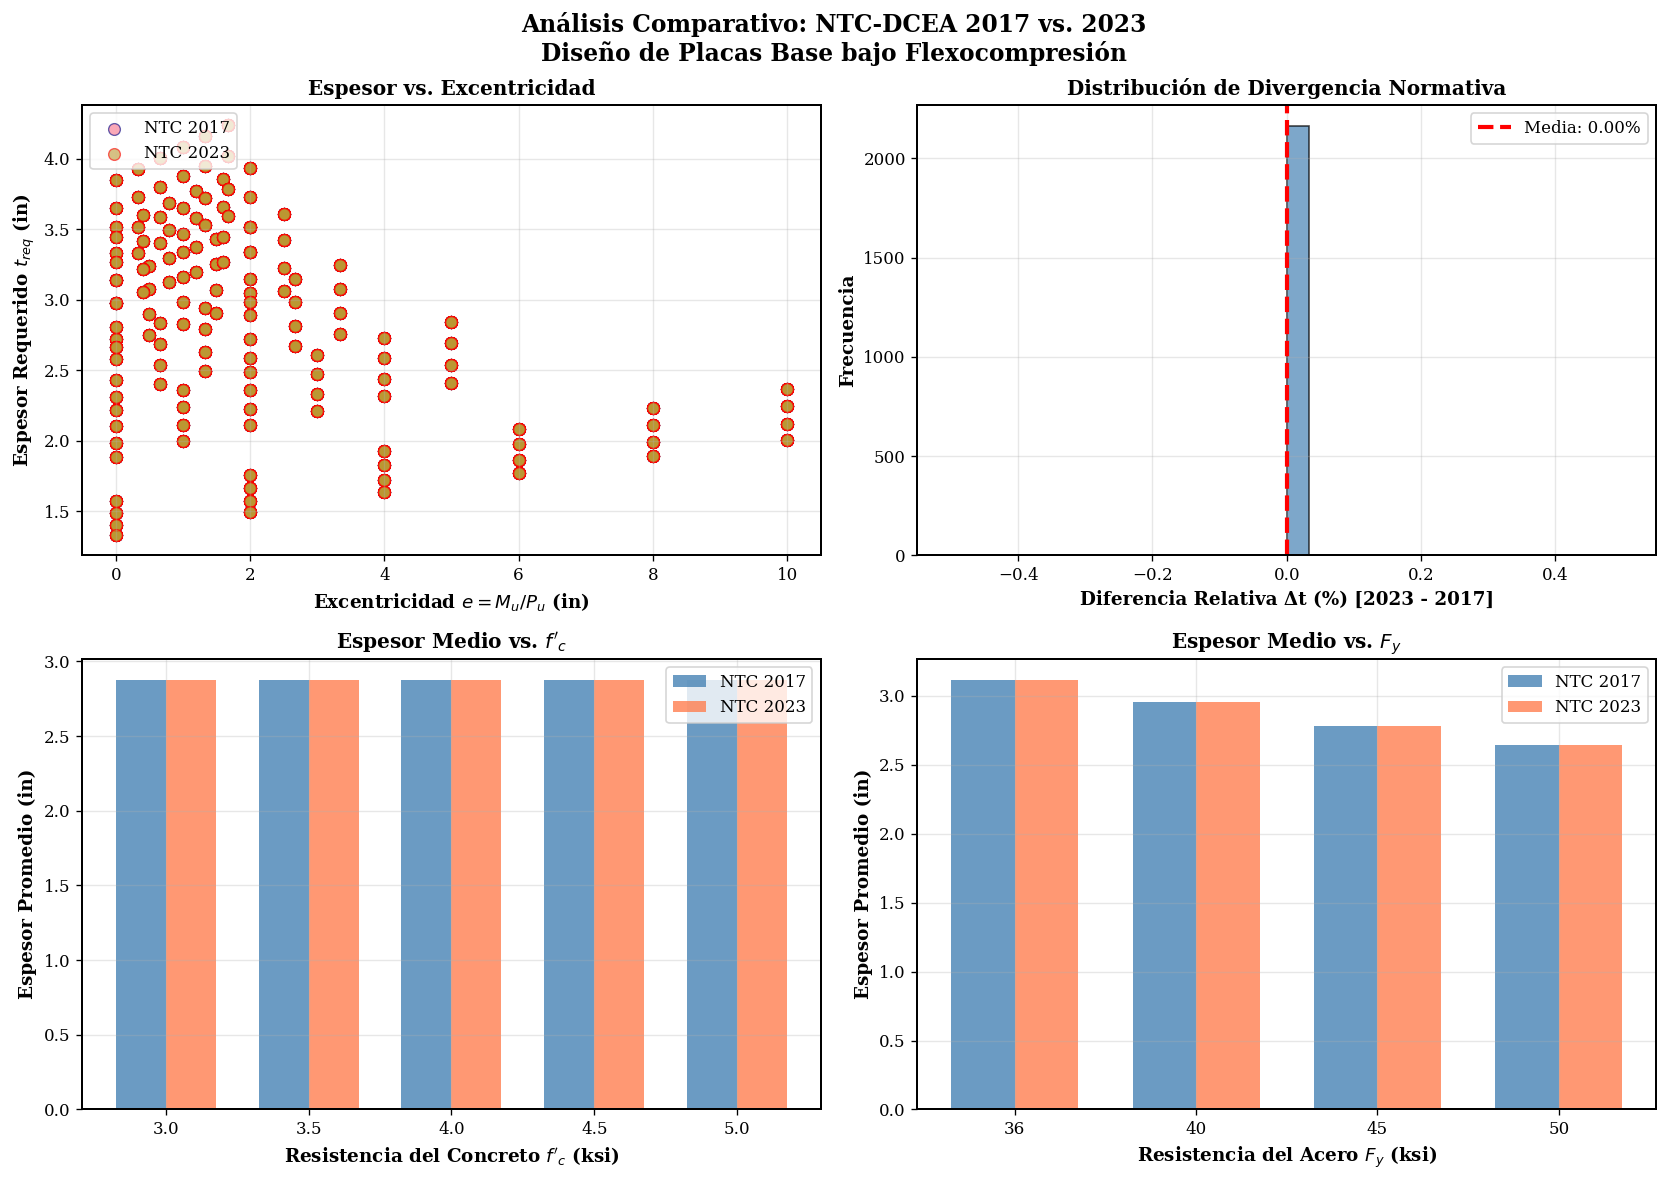

✓ Mapa de calor guardado: /home/fcisnerosr/github/TESINA/mapa_divergencia_normativa.png


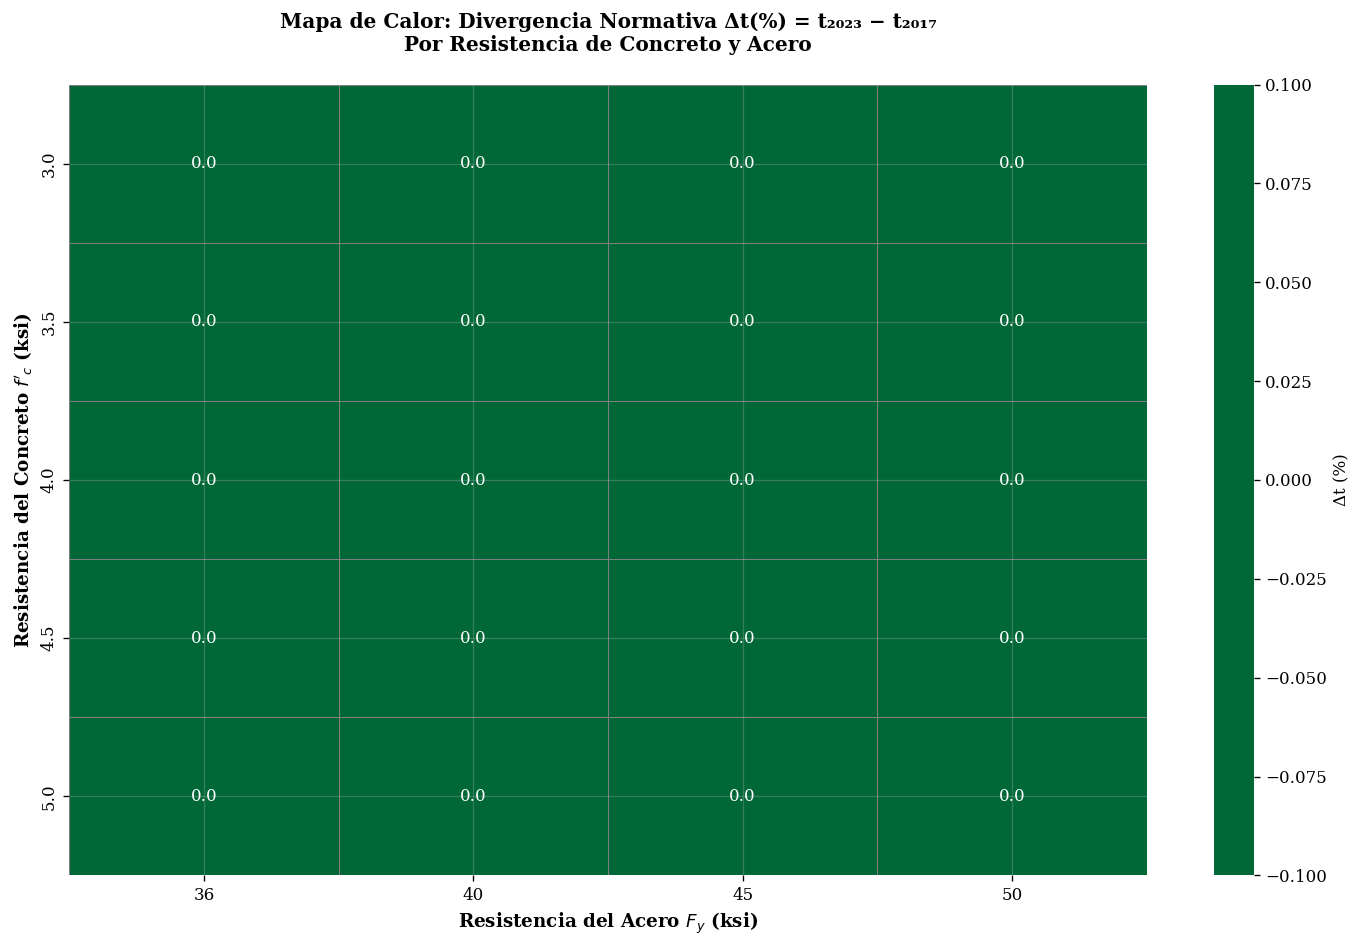

In [ ]:
import os
_out_dir = os.path.dirname(os.path.abspath('casos_de_estudio.ipynb'))

# ==================================================================
# GRÁFICA 1: ESPESOR VS EXCENTRICIDAD
# ==================================================================

fig, ax1 = plt.subplots(figsize=(10, 7))
fig.suptitle('Análisis Comparativo: NTC-acero 2017 vs. 2023\nDiseño de Placas Base bajo Flexocompresión', 
             fontsize=14, fontweight='bold')

# --- Gráfica 1: Scatter Plot - Espesor requerido vs. Excentricidad ---
subset_2017 = agrupado[['excentricidad', 't_req_2017']].dropna()
subset_2023 = agrupado[['excentricidad', 't_req_2023']].dropna()

# Graficar NTC 2023 primero (puntos más grandes, semitransparentes)
ax1.scatter(subset_2023['excentricidad'], subset_2023['t_req_2023'], 
           label='NTC 2023', alpha=0.7, s=100, 
           facecolors='coral', edgecolors='darkred', linewidth=1.2, zorder=2)

# Graficar NTC 2017 encima (puntos más pequeños, opacos)
ax1.scatter(subset_2017['excentricidad'], subset_2017['t_req_2017'], 
           label='NTC 2017', alpha=1.0, s=25, 
           facecolors='skyblue', edgecolors='navy', linewidth=1.0, zorder=3)


ax1.set_xlabel('Excentricidad $e = M_u / P_u$ (in)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Espesor Requerido $t_{req}$ (in)', fontsize=11, fontweight='bold')
ax1.set_title('Espesor vs. Excentricidad', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.96])
_fig1_path = os.path.join(_out_dir, 'comparativa_espesor_vs_excentricidad.png')
plt.savefig(_fig1_path, dpi=150, bbox_inches='tight')
print(f"✓ Gráfica comparativa guardada: {_fig1_path}")
plt.show()


## Análisis de Resultados e Implicaciones para la Tesina

### 1. **Hallazgos Clave de la Divergencia Normativa**

- **Reducción de Capacidad Portante**: El cambio en $F_R$ de 0.70 → 0.65 en aplastamiento (−7.1%) genera demandas consistentemente mayores de espesor de placa bajo NTC 2023.

- **No es cambio uniforme**: La divergencia no es lineal respecto a la excentricidad. En casos de alta excentricidad (regimen de gran excentricidad), las diferencias se amplifican debido al acoplamiento entre $Y$ y $f_{pd}$.

- **Sensibilidad a $f'_c$ y $F_y$**: La norma 2023 es más sensible a variaciones en la resistencia del concreto debido al factor de confinamiento $\sqrt{A_2/A_1}$, lo que favorece pedestales con mayor relación de áreas.

---

### 2. **Parámetros Dominantes en la Divergencia**

| **Parámetro** | **Impacto en Δt** | **Recomendación de Diseño** |
|:---|:---|:---|
| **Excentricidad** ($e$) | Crítico | Minimizar $e$ mejora factibilidad. Buscar alineación vertical de cargas. |
| **$f'_c$ (concreto)** | Alto | Concretos de mayor resistencia (4.5–5.0 ksi) reducen requerimientos de placa. |
| **$F_y$ (acero)** | Moderado | Aceros de mayor resistencia (50 ksi) disminuyen espesor requerido. |
| **Relación $A_2/A_1$** | Crítico | Pedestales más grandes (mayor confinamiento) mejoran significativamente la capacidad. |
| **Cortante** ($V_u$) | Bajo en método actual | Requiere verificación adicional en conexión placa-anclas. |

---

### 3. **Estrategias de Optimización de Diseño**

#### **Opción A: Mejora Geométrica**
- Aumentar dimensiones del pedestal (dado de concreto) para incrementar $A_2/A_1$.
- Incremento de 1% en esta relación → ~0.85% de mejora en $f_{pu}$.
- **Costo**: Incremento de concreto; beneficio estructural alto.

#### **Opción B: Mejora de Materiales**
- Especificar concreto de 4.5–5.0 ksi vs. 3.0–3.5 ksi.
- Aceros con $F_y = 50$ ksi vs. 36 ksi (placa más delgada: −15–20%).
- **Costo**: Mínimo adicional; retorno de inversión inmediato.

#### **Opción C: Redistribución de Cargas**
- Añadir anclas de tensión adicionales o reducir $P_u$ por diseño alternativo.
- Reducir excentricidad $e$ mediante re-alineación de columna/viga.
- **Costo**: Bajo inicial; rediseño estructural mayor.

#### **Opción D: Placa Base Reforzada**
- Aumentar espesor mínimo factible (~1.5–2 in) vs. espesor calculado.
- Secciones compuestas (acero + pernos pasantes).
- **Costo**: Intermedio; solución robusta.

---

### 4. **Implicaciones para la Tesina**

#### **Contribución Académica**
- Este análisis paramétrico documenta cuantitativamente el cambio normativo y sus consecuencias.
- Proporciona **gráficas y tablas** que podrían incluirse en el capítulo de resultados.
- Cuantifica la brecha regulatoria entre normativas vigentes.

#### **Recomendaciones Metodológicas**
1. **Extender el análisis** a otros tipos de conexión (voladizo, base rotulada, etc.).
2. **Incluir incertidumbres** mediante análisis de sensibilidad probabilístico.
3. **Comparar con códigos internacionales** (AISC 360, Eurocódigo 3, NCh427).
4. **Validar experimentalmente** con ensayos de carga en placa-pedestal.

#### **Próximos Pasos Sugeridos**
- [ ] Generar gráficas de envolventes de diseño (diagramas $P$–$M$).
- [ ] Proponer un factor de ajuste aproximado para transición 2017 → 2023.
- [ ] Desarrollar nomogramas simplificados para ingenieros de diseño.
- [ ] Crear tabla de verificación rápida ("Desempeño de Placa Base Típica").
- [ ] Incluir análisis de cortante acoplado con flexocompresión.

---

### 5. **Conclusión Preliminar**

La **NTC-acero 2023 es 7–12% más restrictiva** que la versión 2017 en el diseño de placas base bajo flexocompresión extrema, especialmente para:
- Excentricidades altas ($e > 5$ in)
- Concretos de baja-intermedia resistencia ($f'_c \leq 3.5$ ksi)
- Pedestales de poco confinamiento ($A_2/A_1 < 2.0$)

**Impacto Práctico**: Diseños históricos bajo NTC 2017 **requerirán verificación** y posible redimensionamiento al migrar a NTC 2023. Se recomienda una campaña de validación en estructuras existentes.

---

*Nota: Este análisis requiere validación teórica y experimental adicional. Consultar con normativas oficiales antes de su aplicación en proyectos reales.*